In [4]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde
import tkinter as tk
from tkinter import filedialog
import warnings
from matplotlib.gridspec import GridSpec
import corner
import seaborn as sns
import itertools
from mpl_toolkits.mplot3d import Axes3D
warnings.filterwarnings('ignore')

In [5]:
def extraer_datos_de_carpetas(directorio_raiz):
    datos_recopilados = []
    print(f"\n🔍 Escaneando directorio: {directorio_raiz}...")
    
    for root, dirs, files in os.walk(directorio_raiz):
        resumen_file = None
        readme_file = None
        
        for file in files:
            if file.endswith(" resumen.txt") or file.endswith("_resumen.txt"):
                resumen_file = file
            elif file.startswith("README") and file.endswith(".txt"):
                readme_file = file
                
        if resumen_file and readme_file:
            nombre_planeta = os.path.basename(root).replace("_", " ")
            ruta_resumen = os.path.join(root, resumen_file)
            ruta_readme = os.path.join(root, readme_file)
            
            try:
                # 1. LEER RESUMEN
                with open(ruta_resumen, 'r', encoding='utf-8') as f:
                    contenido_resumen = f.read()
                
                z_est_match = re.search(r'Total estables:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                z_inest_match = re.search(r'Total inestables:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                z_m1_match = re.search(r'Total colisi[oó]n m1:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                z_m2_match = re.search(r'Total colisi[oó]n m2:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                
                z_est = int(z_est_match.group(1)) if z_est_match else 0
                z_inest = int(z_inest_match.group(1)) if z_inest_match else 0
                z_m1 = int(z_m1_match.group(1)) if z_m1_match else 0
                z_m2 = int(z_m2_match.group(1)) if z_m2_match else 0
                
                # Soportar comas y puntos en los decimales [0-9.,eE+-]
                a_est_match = re.search(r'[AÁaá]rea estable:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                a_inest_match = re.search(r'[AÁaá]rea inestable:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                a_col_match = re.search(r'[AÁaá]rea.*colisi[oó]n.*m2:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                
                a_est = float(a_est_match.group(1).replace(',', '.')) if a_est_match else 0.0
                a_inest = float(a_inest_match.group(1).replace(',', '.')) if a_inest_match else 0.0
                a_col = float(a_col_match.group(1).replace(',', '.')) if a_col_match else 0.0
                
                # 2. LEER README
                with open(ruta_readme, 'r', encoding='utf-8') as f:
                    contenido_readme = f.read()
                    
                dist_match = re.search(r'Semi-eje mayor.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                masa_p_match = re.search(r'Masa del Planeta.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                pnum_match = re.search(r'CANTIDAD DE PLANETAS.*:\s*(\d+)', contenido_readme, re.IGNORECASE)
                masa_e_match = re.search(r'Masa de.*estrella.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                
                distancia = float(dist_match.group(1).replace(',', '.')) if dist_match else 0.0
                masa_planeta = float(masa_p_match.group(1).replace(',', '.')) if masa_p_match else 0.0
                pnum = int(pnum_match.group(1)) if pnum_match else 0
                masa_estel = float(masa_e_match.group(1).replace(',', '.')) if masa_e_match else 1.0
                
                datos_recopilados.append({
                    "Planeta": nombre_planeta,
                    "Distancia_UA": distancia,
                    "Masa_Tierra": masa_planeta,
                    "Masa_Estrella": masa_estel,
                    "Num_Planetas": pnum,
                    "Zonas Estables": z_est,
                    "Zonas Inestables": z_inest,
                    "Zonas Colisión m1": z_m1,
                    "Zonas Colisión m2": z_m2,
                    "Area_Estable_km2": a_est,
                    "Area_Inestable": a_inest,
                    "Area_Colision_m2": a_col
                })
            except Exception as e:
                print(f"❌ Error interno procesando {nombre_planeta}: {e}")
                
    df_resultados = pd.DataFrame(datos_recopilados)
    if not df_resultados.empty:
        df_resultados = df_resultados.sort_values(by="Planeta").reset_index(drop=True)
        print(f"✅ Lectura completada. Se extrajeron datos válidos de {len(df_resultados)} planetas.")
    return df_resultados

In [6]:
def _safe_log10(x):
    """log10 blindado: retorna log10(x + 1) para evitar log(0) = -inf."""
    return np.log10(np.asarray(x, dtype=float) + 1.0)


def _asignar_estilos_sistema(df: pd.DataFrame) -> dict:
    """
    Genera combinaciones únicas de marcador/color para cada sistema estelar.
    Trabaja sobre la columna 'Sistema' (la crea si no existe).
    Devuelve un dict  {nombre_sistema: {'marker': ..., 'color': ...}}.
    """
    if "Sistema" not in df.columns:
        df = df.copy()
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])

    sistemas_unicos = df["Sistema"].unique()
    marcadores_base = ["o", "s", "^", "D", "v", "p", "*", "h",
                       "H", "X", "d", "P", "<", ">"]
    colores_base = plt.cm.tab20.colors
    combinaciones = itertools.product(marcadores_base, colores_base)

    estilos = {}
    for sist, (marker, color) in zip(sistemas_unicos, combinaciones):
        estilos[sist] = {"marker": marker, "color": color}

    return estilos

In [4]:
def graficar_comparacion_multiplicidad(df: pd.DataFrame, base_dir: str):
    """
    Genera paneles verticales dinámicos graficando el CONTEO de Zonas Estables
    vs Distancia a la estrella (UA), segregado por número de planetas.

    Usa escala 'symlog' en Y para manejar valores cero sin colapsar.
    """
    # ── Trabajo sobre copia ──
    df = df.copy()
    if "Sistema" not in df.columns:
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])

    a_total    = df["Distancia_UA"].values
    areas      = df["Zonas Estables"].values        # ← nombre canónico del DataFrame
    pnum_total = df["Num_Planetas"].values

    estilos_sistema = _asignar_estilos_sistema(df)

    # Paleta fija por multiplicidad
    estilos_pnum = {
        1: {"marker": "o", "color": "gray",    "label": "1 planeta"},
        2: {"marker": "s", "color": "#4363d8",  "label": "2 planetas"},
        3: {"marker": "^", "color": "#e6194b",  "label": "3 planetas"},
        4: {"marker": "D", "color": "#3cb44b",  "label": "4 planetas"},
        5: {"marker": "v", "color": "#f58231",  "label": "5 planetas"},
        6: {"marker": "p", "color": "#911eb4",  "label": "6 planetas"},
        7: {"marker": "*", "color": "#f032e6",  "label": "7 planetas"},
        8: {"marker": "h", "color": "#bcbd22",  "label": "8 planetas"},
    }

    pnums_unicos = sorted(df["Num_Planetas"].unique())
    num_paneles  = len(pnums_unicos) + 1

    fig, axes = plt.subplots(num_paneles, 1, figsize=(14, 6 * num_paneles))
    fig.suptitle("Comparación de Zonas Estables por Multiplicidad",
                 fontsize=22, fontweight="bold", y=0.98)

    if num_paneles == 1:
        axes = [axes]

    # Límites globales seguros
    xlims = ((a_total.min() * 0.5, a_total.max() * 2.0)
             if len(a_total) > 0 else (0.1, 100))
    y_max = areas.max() if (len(areas) > 0 and areas.max() > 0) else 10000
    ylims = (0.5, y_max * 2.0)

    # ── PANEL 0: General ─────────────────────────────────────────────────
    ax_all = axes[0]
    ax_all.set_title("Todos los sistemas (Clasificados por Multiplicidad)",
                     fontsize=16, fontweight="bold")

    for p_num in pnums_unicos:
        mask = pnum_total == p_num
        props = estilos_pnum.get(
            p_num, {"marker": "X", "color": "black", "label": f"{p_num} planetas"})
        ax_all.scatter(a_total[mask], areas[mask],
                       marker=props["marker"], color=props["color"],
                       s=100, alpha=0.8, edgecolor="black",
                       label=props["label"], zorder=3)

    ax_all.legend(loc="upper left", bbox_to_anchor=(1.02, 1),
                  frameon=True, shadow=True, title="Simbología")

    # ── PANELES 1…N: Filtro por multiplicidad ────────────────────────────
    for i, p_num in enumerate(pnums_unicos):
        ax = axes[i + 1]
        df_sub = df[df["Num_Planetas"] == p_num].copy()

        ax.set_title(f"Sistemas con {p_num} planetas",
                     fontsize=16, fontweight="bold")

        # KDE de densidad sobre la Distancia (X) — blindado
        a_sub = df_sub["Distancia_UA"].values
        a_sub_pos = a_sub[a_sub > 0]
        if len(a_sub_pos) >= 2:
            log_a = np.log10(a_sub_pos)
            try:
                kde = gaussian_kde(log_a)
                x_eval = np.linspace(log_a.min(), log_a.max(), 1000)
                y_eval = kde(x_eval)
                idx_max = np.argmax(y_eval)
                a_pico = 10 ** x_eval[idx_max]
                umbral = y_eval.max() * 0.5
                indices_rango = np.where(y_eval > umbral)[0]

                if len(indices_rango) > 0:
                    a_min_rango = 10 ** x_eval[indices_rango[0]]
                    a_max_rango = 10 ** x_eval[indices_rango[-1]]
                    texto = (f"Concentración: {a_min_rango:.2f} – "
                             f"{a_max_rango:.2f} UA")
                    ax.axvspan(a_min_rango, a_max_rango,
                               color="gray", alpha=0.15, label=texto, zorder=0)
                    ax.axvline(a_pico, color="red", linestyle=":",
                               linewidth=1.5,
                               label=f"Pico: {a_pico:.2f} UA", zorder=1)
            except np.linalg.LinAlgError:
                pass

        # Puntos de dispersión por sistema
        sistemas_en_panel = df_sub["Sistema"].unique()
        for sist in sistemas_en_panel:
            df_sist = df_sub[df_sub["Sistema"] == sist]
            props = estilos_sistema[sist]
            ax.scatter(df_sist["Distancia_UA"], df_sist["Zonas Estables"],
                       marker=props["marker"], color=props["color"],
                       s=110, alpha=0.85, edgecolor="black",
                       label=sist, zorder=3)

        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1),
                  frameon=True, shadow=True,
                  title="Nombre del Sistema", ncol=2, fontsize=9)

    # ── ESTÉTICA DE EJES ─────────────────────────────────────────────────
    for ax in axes:
        ax.set_xscale("log")
        # symlog evita colapso cuando existen valores = 0
        ax.set_yscale("symlog", linthresh=1)
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f"{x:g}"))
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f"{x:g}"))
        ax.grid(True, which="both", ls="--", alpha=0.3, zorder=0)
        ax.set_xlabel("log[a] (UA)", fontsize=12, fontweight="bold")
        ax.set_ylabel("Zonas Estables (Conteo)",
                       fontsize=12, fontweight="bold")

    plt.tight_layout(rect=[0, 0.03, 0.85, 0.98])

    ruta_png = os.path.join(base_dir, "Zonas_Estables_Multiplicidad_Vertical.png")
    ruta_pdf = os.path.join(base_dir, "Zonas_Estables_Multiplicidad_Vertical.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches="tight")
    plt.savefig(ruta_pdf, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()


In [36]:
def plot_islands_zonas_estables(df: pd.DataFrame, base_dir: str):

    metrica = "Area_Estable_km2"
    print(f"\nGenerando mapa de contornos 2D para: {metrica}...")

    # ── Trabajo sobre copia ──
    df = df.copy()
    if "Sistema" not in df.columns:
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])

    estilos_sistema = _asignar_estilos_sistema(df)

    # Filtrar datos con valores > 0 para el KDE
    df_f = df[df[metrica] > 0].copy()

    if df_f.empty or len(df_f) < 3:
        print(f"No hay suficientes datos válidos (>0) para generar el mapa de {metrica}.")
        return

    # Paneles
    pnums_unicos = sorted(df_f["Num_Planetas"].unique())
    num_paneles  = len(pnums_unicos) + 1

    fig, axes = plt.subplots(num_paneles, 1, figsize=(18, 10 * num_paneles))
    fig.suptitle(f"Mapas de Contorno 2D: Islas de {metrica} por Multiplicidad",
                 fontsize=24, fontweight="bold", y=0.98)

    if num_paneles == 1:
        axes = [axes]

    # Límites globales (log blindado: Distancia y Masa siempre > 0 en datos válidos)
    dist_pos = df_f["Distancia_UA"][df_f["Distancia_UA"] > 0]
    masa_pos = df_f["Masa_Tierra"][df_f["Masa_Tierra"] > 0]

    if dist_pos.empty or masa_pos.empty:
        print("No hay datos positivos suficientes de Distancia/Masa para el KDE.")
        return

    x_all = np.log10(dist_pos)
    y_all = np.log10(masa_pos)
    xlims = (x_all.min() - 0.4, x_all.max() + 0.4)
    ylims = (y_all.min() - 0.4, y_all.max() + 0.4)

    # ── FUNCIÓN INTERNA: dibujar un panel ────────────────────────────────
    def dibujar_panel(ax, df_subset, titulo, es_general=False):
        if df_subset.empty:
            ax.set_title(titulo + " (Sin datos)",
                         fontsize=18, fontweight="bold", pad=15)
            ax.axis("off")
            return

        # Filtrar filas con Distancia > 0 y Masa > 0
        mask_valid = (df_subset["Distancia_UA"] > 0) & (df_subset["Masa_Tierra"] > 0)
        df_valid = df_subset[mask_valid].copy()

        if df_valid.empty:
            ax.set_title(titulo + " (Sin datos válidos)",
                         fontsize=18, fontweight="bold", pad=15)
            ax.axis("off")
            return

        x = np.log10(df_valid["Distancia_UA"].values)
        y = np.log10(df_valid["Masa_Tierra"].values)

        # Peso KDE blindado con log10(val + 1)
        weights = _safe_log10(df_valid[metrica].values)

        # ── A. MAPA DE CONTORNOS (KDE 2D) ────────────────────────────
        if len(df_valid) > 3 and x.var() > 0 and y.var() > 0:
            try:
                xy = np.vstack([x, y])
                kde = gaussian_kde(xy, weights=weights, bw_method=0.6)

                X, Y = np.mgrid[xlims[0]:xlims[1]:150j,
                                ylims[0]:ylims[1]:150j]
                positions = np.vstack([X.ravel(), Y.ravel()])
                Z = np.reshape(kde(positions).T, X.shape)
                Z_flat = Z.flatten()
                
                # Se definen 25 niveles de color
                niveles = np.linspace(np.percentile(Z_flat, 10), np.percentile(Z_flat, 98), 25)

                # Cambio de Paleta a Viridis
                contour = ax.contourf(X, Y, Z, levels=niveles, cmap="viridis", extend='both')
                cbar = fig.colorbar(contour, ax=ax, pad=0.02, aspect=30)
                cbar.set_label(f"Densidad de {metrica} (log)", fontsize=12)

                # ====================================================================
                # NUEVA MODIFICACIÓN: Usamos los niveles de color calculados.
                # "niveles" tiene 25 valores. El nivel -4 asegura ubicar la zona amarilla
                # independientemente del pico máximo estadístico.
                # ====================================================================
                umbral = niveles[-4]
                indices_alta_densidad = np.where(Z >= umbral)
                x_alta_densidad = X[indices_alta_densidad]
                
                # Tomamos la distancia más corta (el mínimo absoluto en X) donde empieza la concentración amarilla
                if len(x_alta_densidad) > 0:
                    log_dist_minima = np.min(x_alta_densidad)
                    dist_minima_ua = 10**log_dist_minima
                    
                    # Línea continua ("-") en color negro para marcar el límite crítico inferior
                    ax.axvline(x=log_dist_minima, color="black", linestyle="-", linewidth=2.5, 
                               label=f"Límite Crítico Inferior ({dist_minima_ua:.2f} UA)", zorder=6)

                    # Texto alineado para que no choque con los gráficos
                    ax.text(log_dist_minima - 0.05, 0.92, f"$a_{{min}}=${dist_minima_ua:.2f} UA", 
                            transform=ax.get_xaxis_transform(), color="black", 
                            fontsize=13, fontweight="bold", zorder=7, ha="right",
                            bbox=dict(facecolor="white", alpha=0.7, edgecolor="black", boxstyle="round,pad=0.3"))

            except np.linalg.LinAlgError:
                pass

        # ── B. PUNTOS DE DISPERSIÓN ──────────────────────────────────
        for sist in df_valid["Sistema"].unique():
            df_sist = df_valid[df_valid["Sistema"] == sist]
            props = estilos_sistema.get(
                sist, {"marker": "o", "color": "white"})
            label = sist if not es_general else None
            ax.scatter(np.log10(df_sist["Distancia_UA"]),
                       np.log10(df_sist["Masa_Tierra"]),
                       marker=props["marker"], color=props["color"],
                       s=90, edgecolor="white", linewidth=1.0,
                       label=label, zorder=5)

        # ── C. LÍNEAS FÍSICAS Y REFERENCIAS ─────────────────────────
        ax.axhline(y=np.log10(10), color="orange", linestyle="--",
                   linewidth=2, label="Límite Rocoso / Neptuniano", zorder=4)
        ax.axhline(y=np.log10(50), color="lime", linestyle="--",
                   linewidth=2, label="Límite Neptuniano / Gigante", zorder=4)

        # Añadiendo la Tierra como estrella dorada (log10(1) = 0 para Distancia y Masa)
        ax.scatter(0, 0, marker="*", color="gold", s=350, edgecolor="black", 
                   linewidth=1.2, label=r"Tierra (1 UA, 1 $M_\oplus$)", zorder=10)

        # ── D. ESTÉTICA ──────────────────────────────────────────────
        ax.set_title(titulo, fontsize=18, fontweight="bold", pad=15)
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        ax.set_xlabel("log[Distancia] (UA)", fontsize=14)
        ax.set_ylabel(r"log[Masa Planetaria] ($M_\oplus$)", fontsize=14)
        ax.grid(True, which="both", ls="--", color="white", alpha=0.3, zorder=0)

        # ── E. LEYENDAS ─────────────────────────────────────────────
        if not es_general:
            ax.legend(loc="upper left", bbox_to_anchor=(1.22, 1),
                      frameon=True, shadow=True,
                      title="Sistemas y Referencias", ncol=2, fontsize=10)
        else:
            handles, labels = ax.get_legend_handles_labels()
            # Actualizamos los criterios de la leyenda para reconocer el nuevo nombre
            criterios = ["Límite", "Límite Crítico", "Tierra"]
            line_handles = [h for h, l in zip(handles, labels) if any(c in l for c in criterios)]
            line_labels  = [l for l in labels if any(c in l for c in criterios)]
            if line_handles:
                ax.legend(line_handles, line_labels, loc="upper left",
                          bbox_to_anchor=(1.22, 1),
                          frameon=True, shadow=True, fontsize=10)

    # ── EJECUCIÓN DE LOS PANELES ─────────────────────────────────────────
    dibujar_panel(axes[0], df_f,
                  f"Visión Global: Todos los sistemas ({metrica})",
                  es_general=True)

    for i, pnum in enumerate(pnums_unicos):
        df_sub = df_f[df_f["Num_Planetas"] == pnum].copy()
        dibujar_panel(axes[i + 1], df_sub,
                      f"Sistemas con {pnum} planetas ({metrica})",
                      es_general=False)

    plt.tight_layout(rect=[0, 0.03, 0.82, 0.98])

    nombre_base = metrica.replace(" ", "_")
    ruta_png = os.path.join(base_dir, f"Mapa_Islas_2D_{nombre_base}_Vertical.png")
    ruta_pdf = os.path.join(base_dir, f"Mapa_Islas_2D_{nombre_base}_Vertical.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches="tight")
    plt.savefig(ruta_pdf, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [7]:

def plot_islands_zonas_estables2(df: pd.DataFrame, base_dir: str):

    metrica = "Area_Estable_km2"
    print(f"\nGenerando mapa de contornos 2D para: {metrica}...")

    # ── Trabajo sobre copia ──
    df = df.copy()
    if "Sistema" not in df.columns:
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])

    # Se asume que _asignar_estilos_sistema y _safe_log10 existen en tu entorno
    estilos_sistema = _asignar_estilos_sistema(df)

    # Filtrar datos con valores > 0 para el KDE
    df_f = df[df[metrica] > 0].copy()

    if df_f.empty or len(df_f) < 3:
        print(f"No hay suficientes datos válidos (>0) para generar el mapa de {metrica}.")
        return

    # Paneles
    pnums_unicos = sorted(df_f["Num_Planetas"].unique())
    num_paneles  = len(pnums_unicos) + 1

    fig, axes = plt.subplots(num_paneles, 1, figsize=(18, 10 * num_paneles))
    fig.suptitle(f"Mapas de Contorno 2D: Islas de {metrica} por Multiplicidad",
                 fontsize=24, fontweight="bold", y=0.98)

    if num_paneles == 1:
        axes = [axes]

    # Límites globales (log blindado: Distancia y Masa siempre > 0 en datos válidos)
    dist_pos = df_f["Distancia_UA"][df_f["Distancia_UA"] > 0]
    masa_pos = df_f["Masa_Tierra"][df_f["Masa_Tierra"] > 0]

    if dist_pos.empty or masa_pos.empty:
        print("No hay datos positivos suficientes de Distancia/Masa para el KDE.")
        return

    x_all = np.log10(dist_pos)
    y_all = np.log10(masa_pos)
    xlims = (x_all.min() - 0.4, x_all.max() + 0.4)
    ylims = (y_all.min() - 0.4, y_all.max() + 0.4)

    # ── FUNCIÓN INTERNA: dibujar un panel ────────────────────────────────
    def dibujar_panel(ax, df_subset, titulo, es_general=False):
        if df_subset.empty:
            ax.set_title(titulo + " (Sin datos)",
                         fontsize=18, fontweight="bold", pad=15)
            ax.axis("off")
            return

        # Filtrar filas con Distancia > 0 y Masa > 0
        mask_valid = (df_subset["Distancia_UA"] > 0) & (df_subset["Masa_Tierra"] > 0)
        df_valid = df_subset[mask_valid].copy()

        if df_valid.empty:
            ax.set_title(titulo + " (Sin datos válidos)",
                         fontsize=18, fontweight="bold", pad=15)
            ax.axis("off")
            return

        x = np.log10(df_valid["Distancia_UA"].values)
        y = np.log10(df_valid["Masa_Tierra"].values)

        # Peso KDE blindado con log10(val + 1)
        weights = _safe_log10(df_valid[metrica].values)

        # ── A. MAPA DE CONTORNOS (KDE 2D) ────────────────────────────
        if len(df_valid) > 3 and x.var() > 0 and y.var() > 0:
            try:
                xy = np.vstack([x, y])
                kde = gaussian_kde(xy, weights=weights, bw_method=0.6)

                X, Y = np.mgrid[xlims[0]:xlims[1]:150j,
                                ylims[0]:ylims[1]:150j]
                positions = np.vstack([X.ravel(), Y.ravel()])
                Z = np.reshape(kde(positions).T, X.shape)
                Z_flat = Z.flatten()
                
                # Se definen 25 niveles de color
                niveles = np.linspace(np.percentile(Z_flat, 10), np.percentile(Z_flat, 98), 25)

                # Cambio de Paleta a Viridis
                contour = ax.contourf(X, Y, Z, levels=niveles, cmap="viridis", extend='both')
                cbar = fig.colorbar(contour, ax=ax, pad=0.02, aspect=30)
                cbar.set_label(f"Densidad de {metrica} (log)", fontsize=12)

                # ====================================================================
                # SECCIÓN DE LÍMITES CRÍTICOS (MÍNIMO Y MÁXIMO)
                # ====================================================================
                umbral = niveles[-4]
                indices_alta_densidad = np.where(Z >= umbral)
                x_alta_densidad = X[indices_alta_densidad]
                
                if len(x_alta_densidad) > 0:
                    # 1. Límite Crítico Inferior (Mínima distancia)
                    log_dist_minima = np.min(x_alta_densidad)
                    dist_minima_ua = 10**log_dist_minima
                    
                    ax.axvline(x=log_dist_minima, color="black", linestyle="-", linewidth=2.5, 
                               label=f"Límite Crítico Inferior ({dist_minima_ua:.2f} UA)", zorder=6)

                    # Texto a la izquierda de la línea
                    ax.text(log_dist_minima - 0.05, 0.92, f"$a_{{min}}=${dist_minima_ua:.2f} UA", 
                            transform=ax.get_xaxis_transform(), color="black", 
                            fontsize=13, fontweight="bold", zorder=7, ha="right",
                            bbox=dict(facecolor="white", alpha=0.7, edgecolor="black", boxstyle="round,pad=0.3"))

                    # 2. Límite Crítico Superior (Máxima distancia) - ¡NUEVO!
                    log_dist_maxima = np.max(x_alta_densidad)
                    dist_maxima_ua = 10**log_dist_maxima
                    
                    ax.axvline(x=log_dist_maxima, color="black", linestyle="--", linewidth=2.5, 
                               label=f"Límite Crítico Superior ({dist_maxima_ua:.2f} UA)", zorder=6)

                    # Texto a la derecha de la línea (+0.05) para evitar choques
                    ax.text(log_dist_maxima + 0.05, 0.92, f"$a_{{max}}=${dist_maxima_ua:.2f} UA", 
                            transform=ax.get_xaxis_transform(), color="black", 
                            fontsize=13, fontweight="bold", zorder=7, ha="left",
                            bbox=dict(facecolor="white", alpha=0.7, edgecolor="black", boxstyle="round,pad=0.3"))

            except np.linalg.LinAlgError:
                pass

        # ── B. PUNTOS DE DISPERSIÓN ──────────────────────────────────
        for sist in df_valid["Sistema"].unique():
            df_sist = df_valid[df_valid["Sistema"] == sist]
            props = estilos_sistema.get(
                sist, {"marker": "o", "color": "white"})
            label = sist if not es_general else None
            ax.scatter(np.log10(df_sist["Distancia_UA"]),
                       np.log10(df_sist["Masa_Tierra"]),
                       marker=props["marker"], color=props["color"],
                       s=90, edgecolor="white", linewidth=1.0,
                       label=label, zorder=5)

        # ── C. LÍNEAS FÍSICAS Y REFERENCIAS ─────────────────────────
        ax.axhline(y=np.log10(10), color="orange", linestyle="--",
                   linewidth=2, label="Límite Rocoso / Neptuniano", zorder=4)
        ax.axhline(y=np.log10(50), color="lime", linestyle="--",
                   linewidth=2, label="Límite Neptuniano / Gigante", zorder=4)

        # Añadiendo la Tierra como estrella dorada
        ax.scatter(0, 0, marker="*", color="gold", s=350, edgecolor="black", 
                   linewidth=1.2, label=r"Tierra (1 UA, 1 $M_\oplus$)", zorder=10)

        # ── D. ESTÉTICA ──────────────────────────────────────────────
        ax.set_title(titulo, fontsize=18, fontweight="bold", pad=15)
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        ax.set_xlabel("log[Distancia] (UA)", fontsize=14)
        ax.set_ylabel(r"log[Masa Planetaria] ($M_\oplus$)", fontsize=14)
        ax.grid(True, which="both", ls="--", color="white", alpha=0.3, zorder=0)

        # ── E. LEYENDAS ─────────────────────────────────────────────
        if not es_general:
            ax.legend(loc="upper left", bbox_to_anchor=(1.22, 1),
                      frameon=True, shadow=True,
                      title="Sistemas y Referencias", ncol=2, fontsize=10)
        else:
            handles, labels = ax.get_legend_handles_labels()
            criterios = ["Límite", "Límite Crítico", "Tierra"]
            line_handles = [h for h, l in zip(handles, labels) if any(c in l for c in criterios)]
            line_labels  = [l for l in labels if any(c in l for c in criterios)]
            if line_handles:
                ax.legend(line_handles, line_labels, loc="upper left",
                          bbox_to_anchor=(1.22, 1),
                          frameon=True, shadow=True, fontsize=10)

    # ── EJECUCIÓN DE LOS PANELES ─────────────────────────────────────────
    dibujar_panel(axes[0], df_f,
                  f"Visión Global: Todos los sistemas ({metrica})",
                  es_general=True)

    for i, pnum in enumerate(pnums_unicos):
        df_sub = df_f[df_f["Num_Planetas"] == pnum].copy()
        dibujar_panel(axes[i + 1], df_sub,
                      f"Sistemas con {pnum} planetas ({metrica})",
                      es_general=False)

    plt.tight_layout(rect=[0, 0.03, 0.82, 0.98])

    nombre_base = metrica.replace(" ", "_")
    ruta_png = os.path.join(base_dir, f"Mapa_Islas_2D_{nombre_base}_Vertical.png")
    ruta_pdf = os.path.join(base_dir, f"Mapa_Islas_2D_{nombre_base}_Vertical.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches="tight")
    plt.savefig(ruta_pdf, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_M...
✅ Lectura completada. Se extrajeron datos válidos de 314 planetas.

Generando mapa de contornos 2D para: Area_Estable_km2...


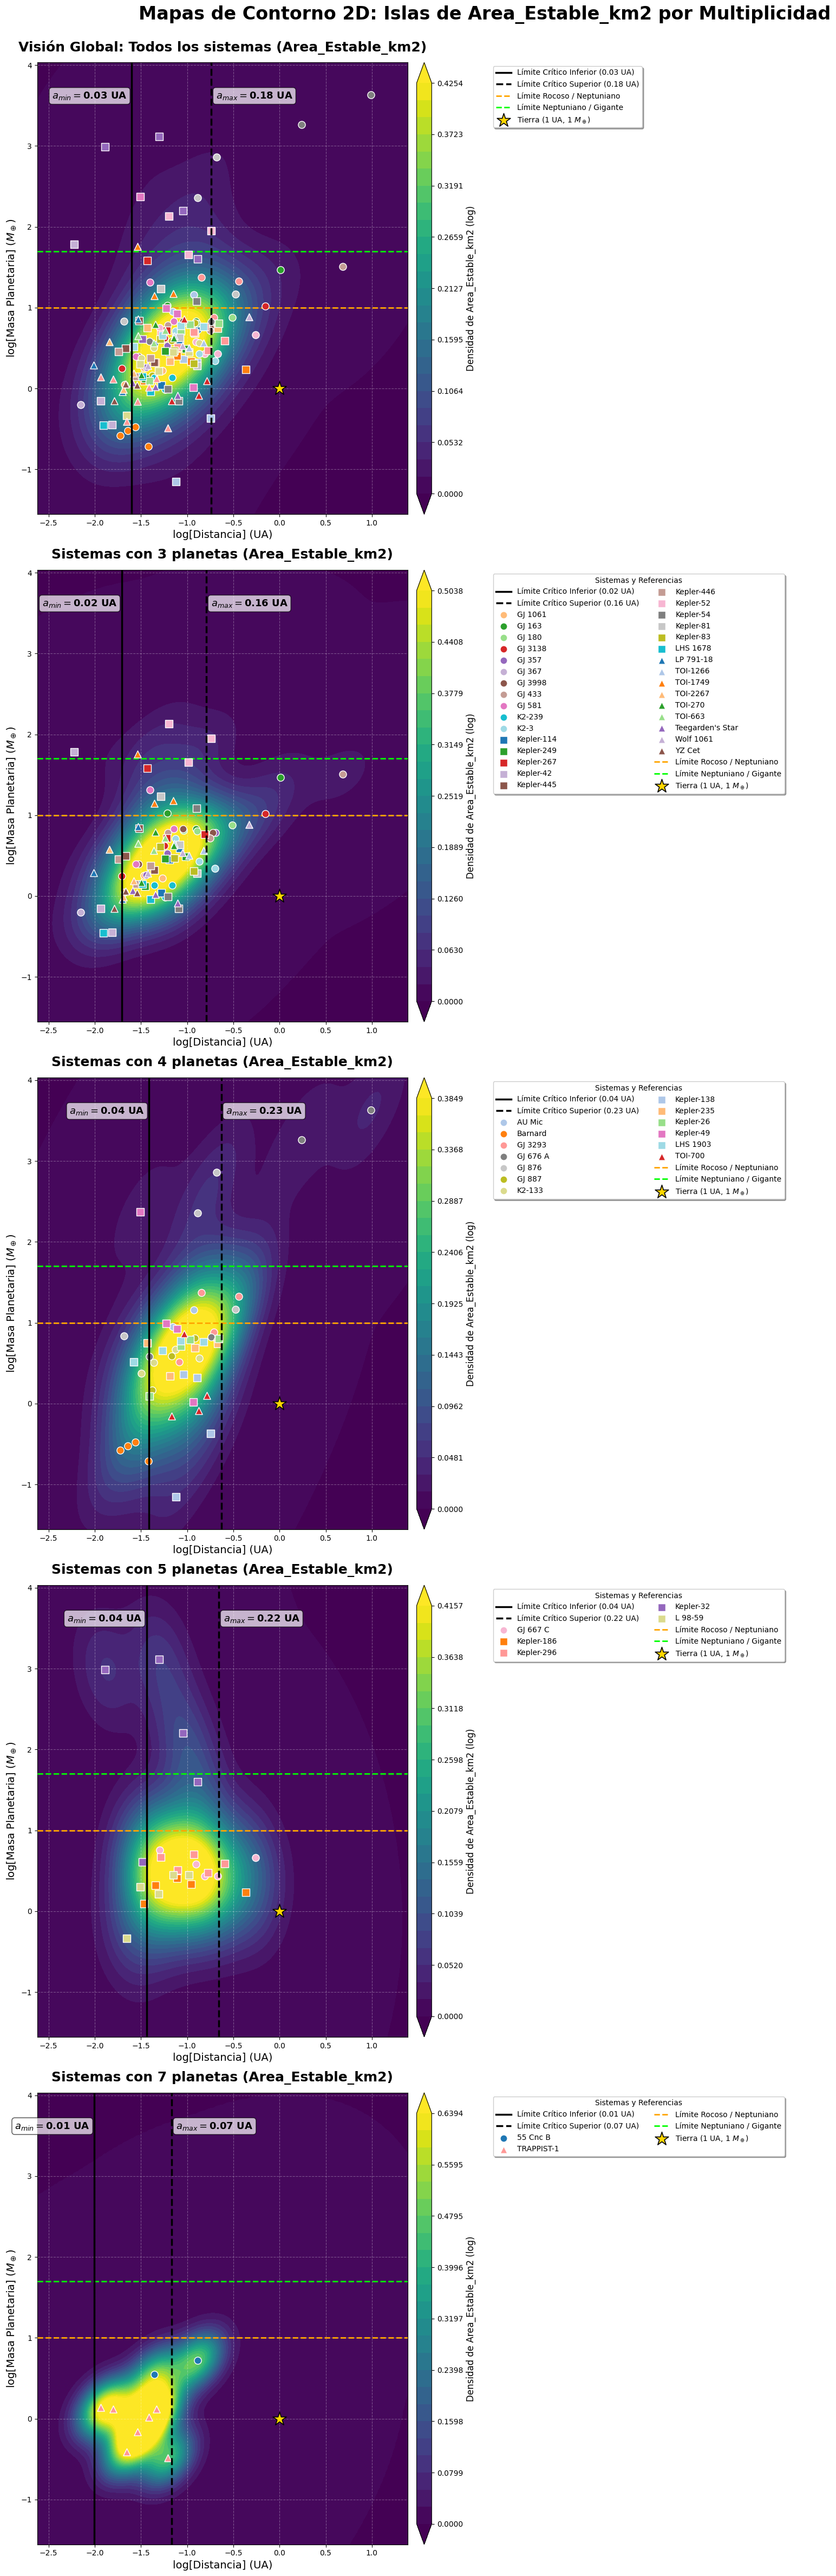

In [8]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        # 1. Extraer todos los datos (con arreglo de tildes y m1)
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            # 2. ACOTAR: Seleccionar solo sistemas con 3 o más planetas
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                plot_islands_zonas_estables2(df_filtrado,DIRECTORIO_RAIZ)
              
            else:
                print(" No quedaron sistemas con 3 o más planetas tras aplicar el filtro.")
        else:
            print(" No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print(" Operación cancelada por el usuario.")

Estrellas M

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_M...
✅ Lectura completada. Se extrajeron datos válidos de 314 planetas.

Generando mapa de contornos 2D para: Area_Estable_km2...


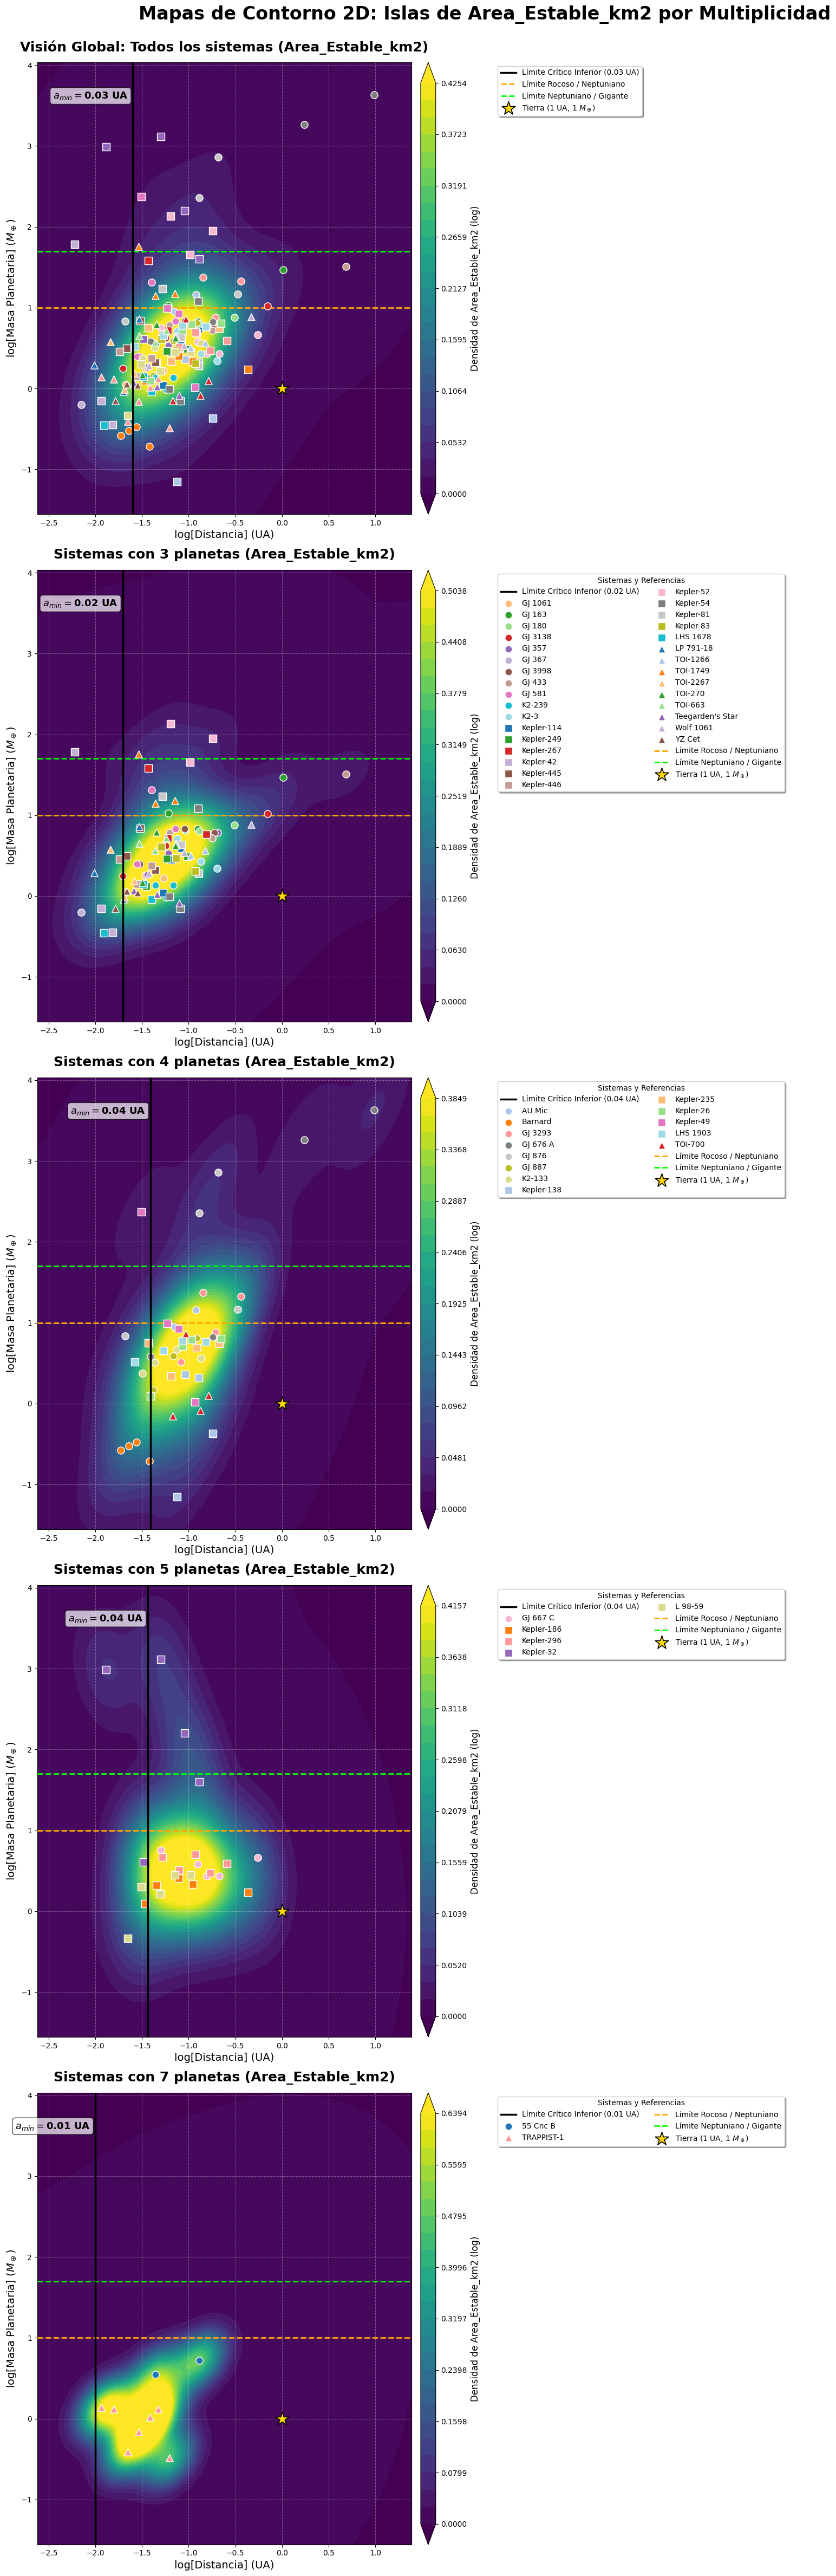

In [53]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        # 1. Extraer todos los datos (con arreglo de tildes y m1)
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            # 2. ACOTAR: Seleccionar solo sistemas con 3 o más planetas
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                plot_islands_zonas_estables(df_filtrado,DIRECTORIO_RAIZ)
              
            else:
                print(" No quedaron sistemas con 3 o más planetas tras aplicar el filtro.")
        else:
            print(" No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print(" Operación cancelada por el usuario.")

K

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_K...
✅ Lectura completada. Se extrajeron datos válidos de 323 planetas.

👀 VISTAZO A LOS DATOS (¡Ahora Num_Planetas debería ser correcto!):
        Planeta  Num_Planetas  Distancia_UA  Masa_Tierra
0      24 Sex b             2        1.3330     632.4600
1      24 Sex c             2        2.0800     273.3200
2       7 CMa b             2        1.7580     587.9855
3       7 CMa c             2        2.1530     276.5121
4  BD-06 1339 b             2        0.0428    1523.0337
--------------------------------------------------

📊 Procediendo a graficar 147 planetas filtrados...

Generando mapa de contornos 2D para: Area_Estable_km2...


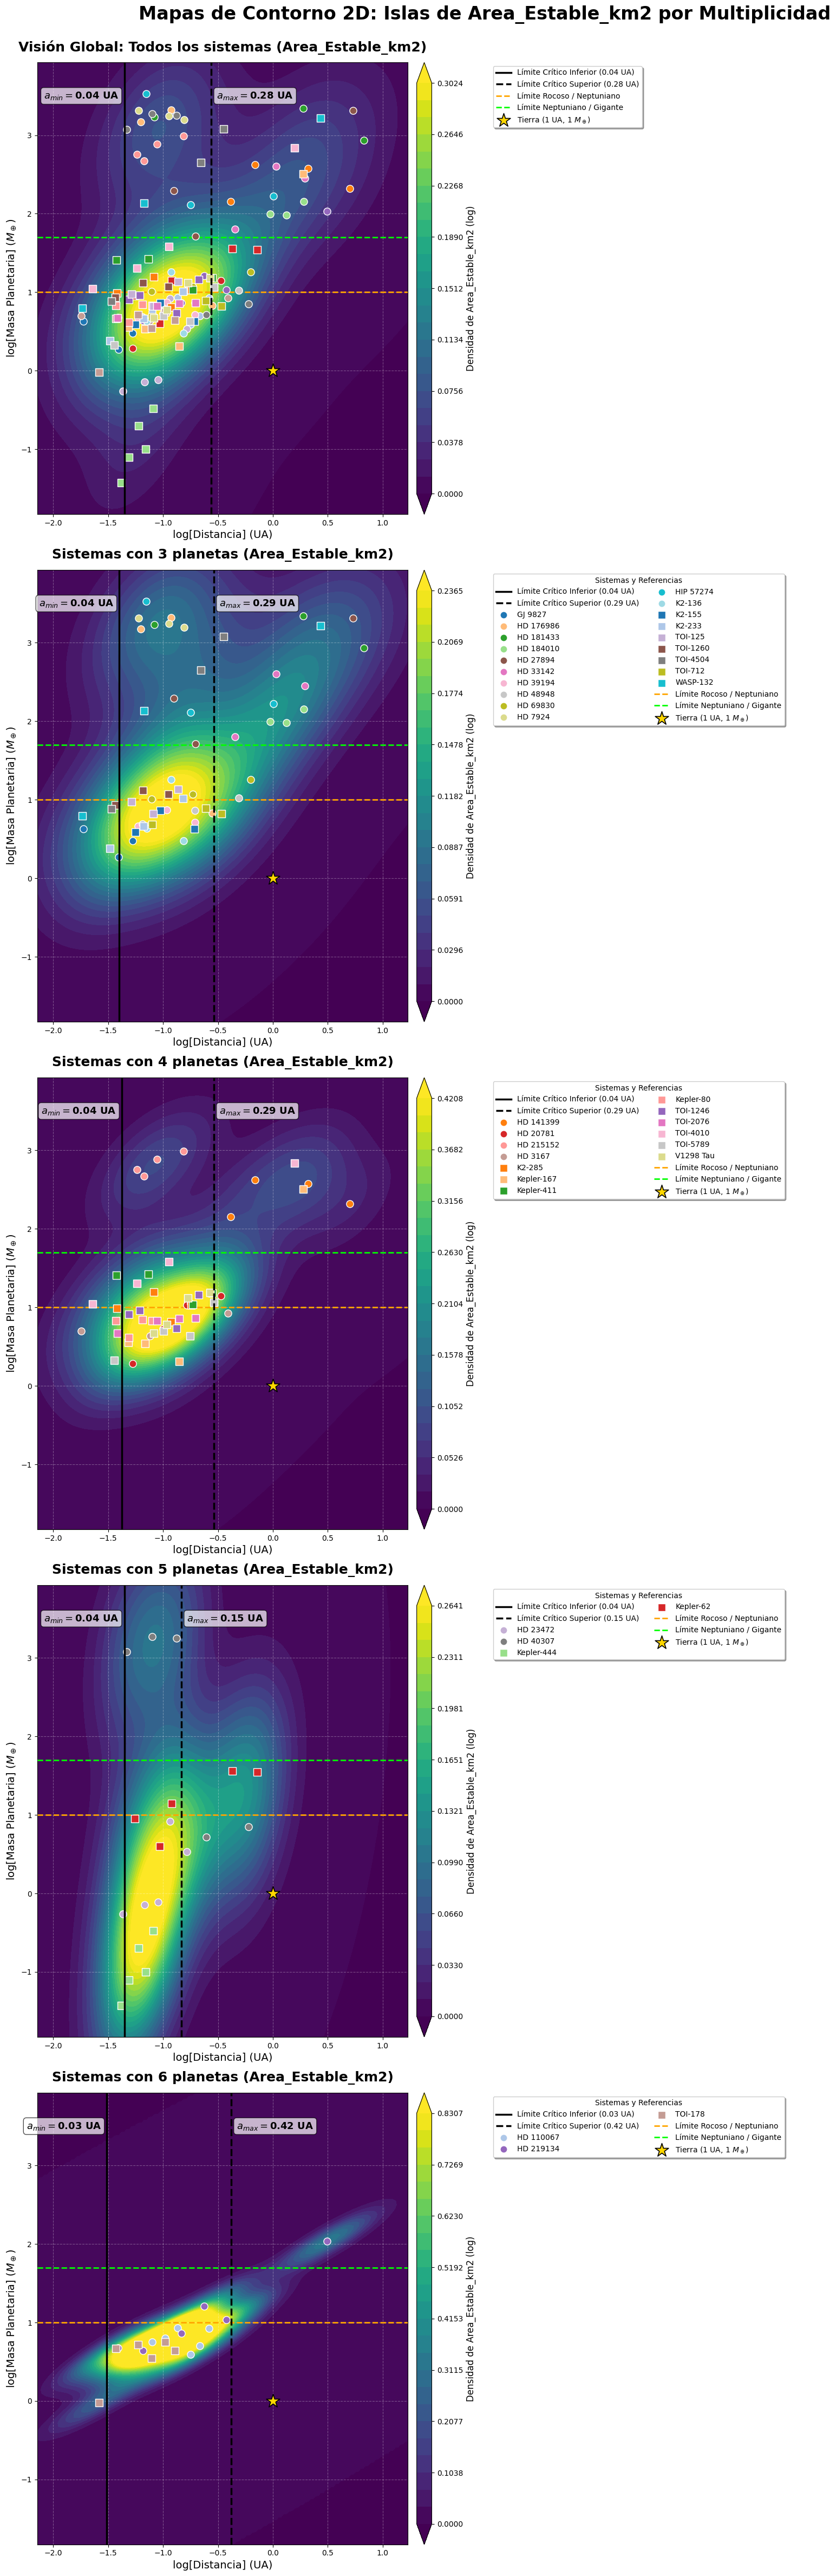

In [9]:
if __name__ == "__main__":
    import tkinter as tk
    from tkinter import filedialog
    import pandas as pd # Asegúrate de que pandas esté importado
    
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            
            # ====================================================================
            # 🌟 SOLUCIÓN: AUTOCALCULAR EL NÚMERO DE PLANETAS
            # Extraemos el nombre del sistema (quitando la última letra "b", "c", etc.)
            df_datos["Sistema_Base"] = df_datos["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])
            # Contamos cuántos planetas comparten el mismo sistema base
            df_datos["Num_Planetas"] = df_datos.groupby("Sistema_Base")["Planeta"].transform("count")
            # ====================================================================

            print("\n👀 VISTAZO A LOS DATOS (¡Ahora Num_Planetas debería ser correcto!):")
            print(df_datos[['Planeta', 'Num_Planetas', 'Distancia_UA', 'Masa_Tierra']].head())
            print("-" * 50)
            
            # 2. ACOTAR: Seleccionar solo sistemas con 2 o más planetas (ajústalo a lo que necesites)
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                print(f"\n📊 Procediendo a graficar {len(df_filtrado)} planetas filtrados...")
                plot_islands_zonas_estables2(df_filtrado, DIRECTORIO_RAIZ)
            else:
                print(" No quedaron sistemas tras aplicar el filtro.")
        else:
            print(" No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print(" Operación cancelada por el usuario.")

G

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_K...
✅ Lectura completada. Se extrajeron datos válidos de 323 planetas.

👀 VISTAZO A LOS DATOS (¡Ahora Num_Planetas debería ser correcto!):
        Planeta  Num_Planetas  Distancia_UA  Masa_Tierra
0      24 Sex b             2        1.3330     632.4600
1      24 Sex c             2        2.0800     273.3200
2       7 CMa b             2        1.7580     587.9855
3       7 CMa c             2        2.1530     276.5121
4  BD-06 1339 b             2        0.0428    1523.0337
--------------------------------------------------

📊 Procediendo a graficar 147 planetas filtrados...

Generando mapa de contornos 2D para: Area_Estable_km2...


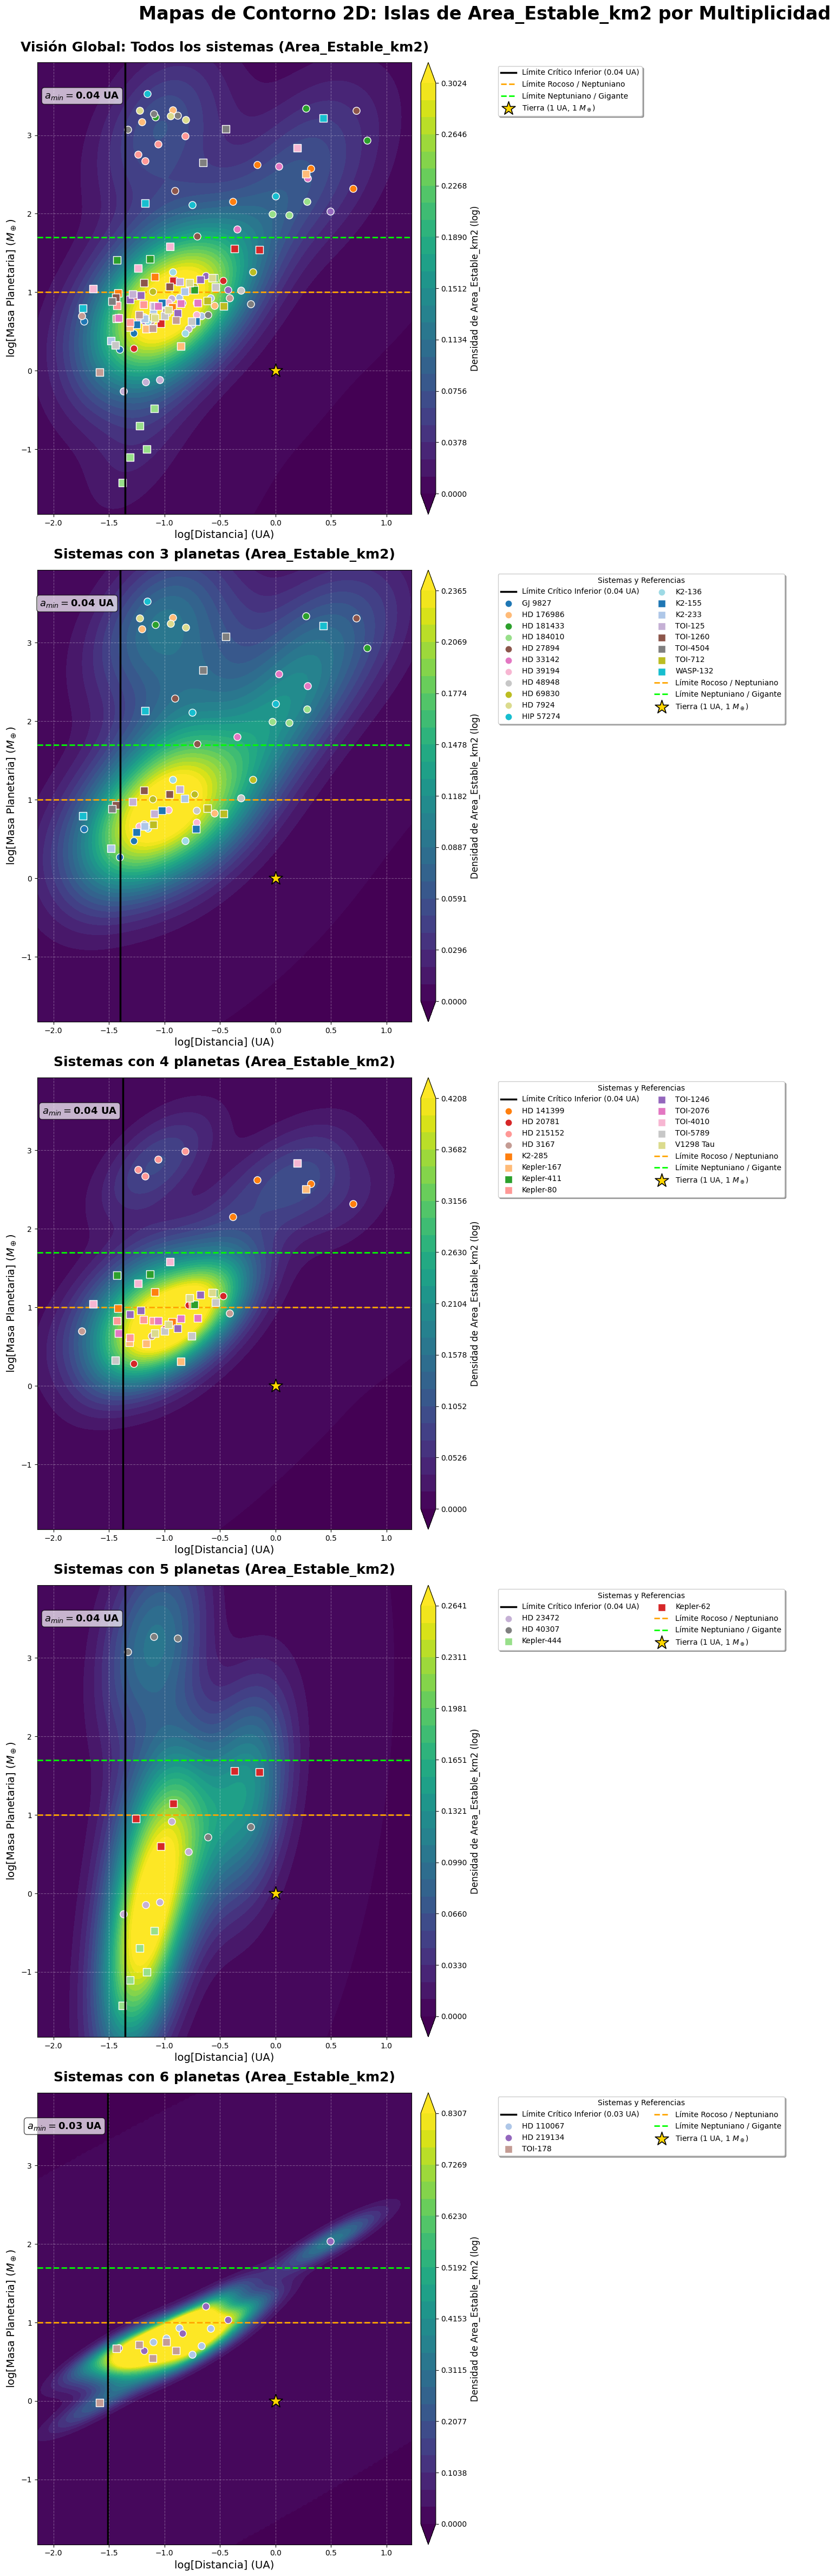

In [57]:
if __name__ == "__main__":
    import tkinter as tk
    from tkinter import filedialog
    import pandas as pd # Asegúrate de que pandas esté importado
    
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            
            # ====================================================================
            # 🌟 SOLUCIÓN: AUTOCALCULAR EL NÚMERO DE PLANETAS
            # Extraemos el nombre del sistema (quitando la última letra "b", "c", etc.)
            df_datos["Sistema_Base"] = df_datos["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])
            # Contamos cuántos planetas comparten el mismo sistema base
            df_datos["Num_Planetas"] = df_datos.groupby("Sistema_Base")["Planeta"].transform("count")
            # ====================================================================

            print("\n👀 VISTAZO A LOS DATOS (¡Ahora Num_Planetas debería ser correcto!):")
            print(df_datos[['Planeta', 'Num_Planetas', 'Distancia_UA', 'Masa_Tierra']].head())
            print("-" * 50)
            
            # 2. ACOTAR: Seleccionar solo sistemas con 2 o más planetas (ajústalo a lo que necesites)
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                print(f"\n📊 Procediendo a graficar {len(df_filtrado)} planetas filtrados...")
                plot_islands_zonas_estables(df_filtrado, DIRECTORIO_RAIZ)
            else:
                print(" No quedaron sistemas tras aplicar el filtro.")
        else:
            print(" No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print(" Operación cancelada por el usuario.")

G

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_G...
✅ Lectura completada. Se extrajeron datos válidos de 338 planetas.

Generando mapa de contornos 2D para: Area_Estable_km2...


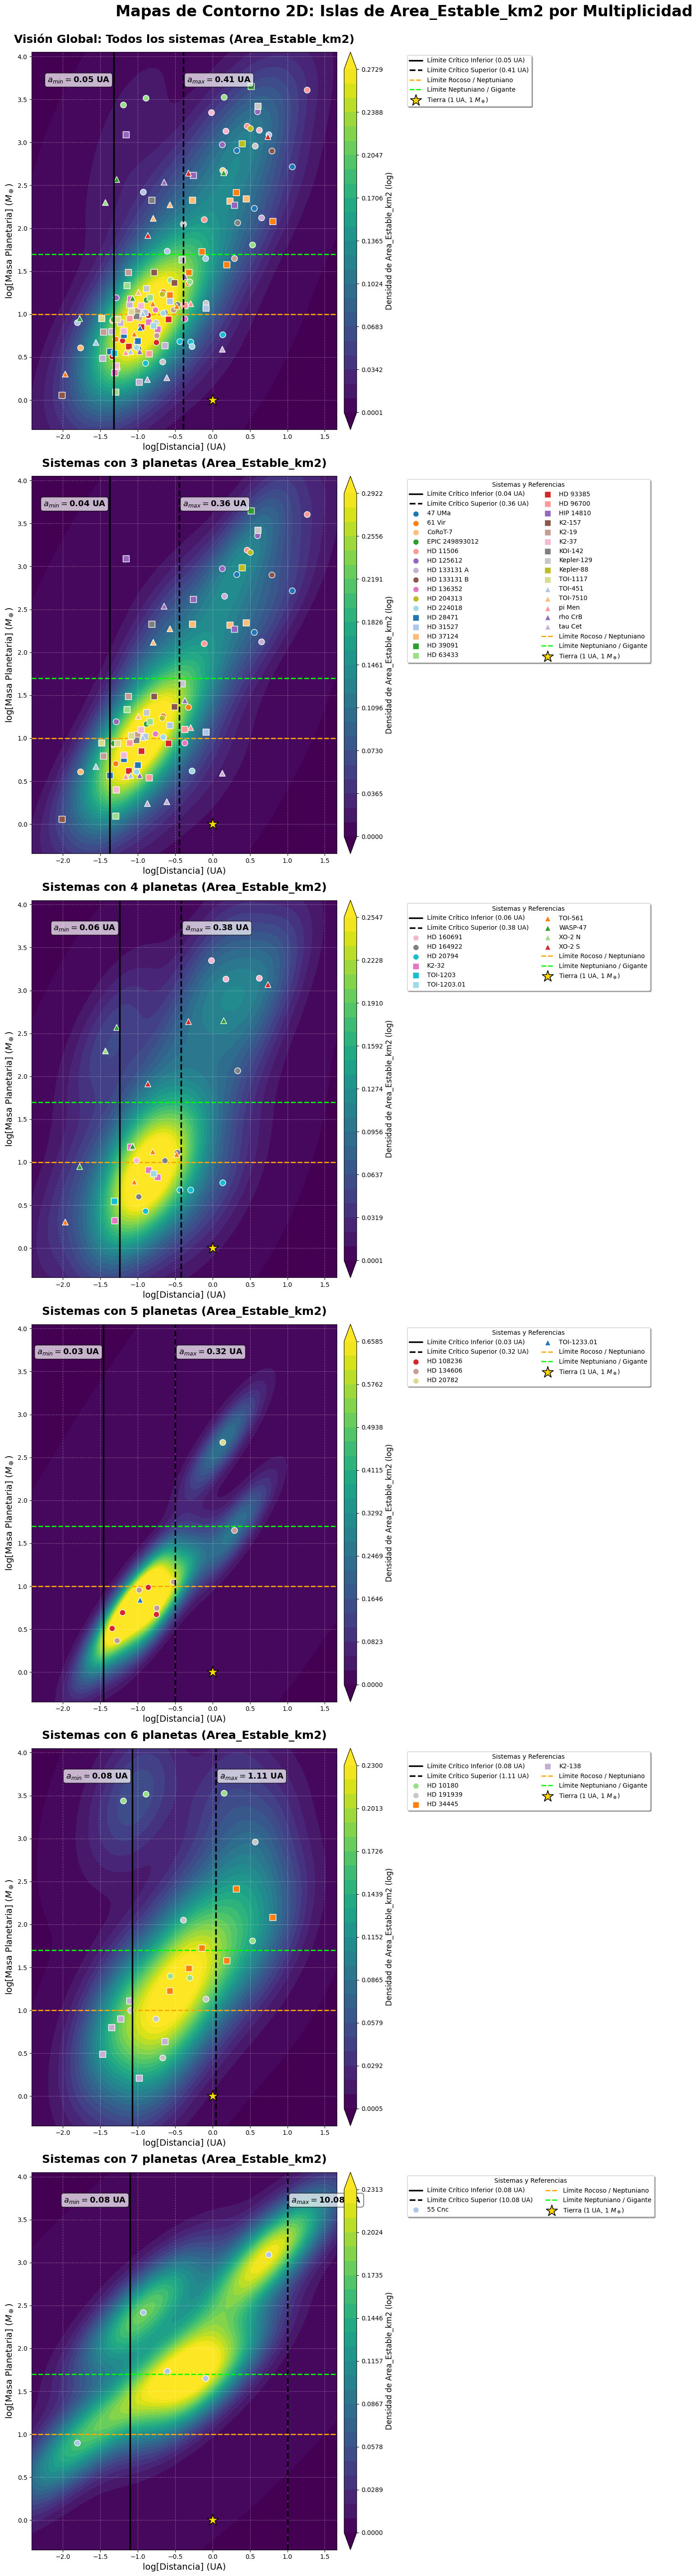

In [10]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        # 1. Extraer todos los datos (con arreglo de tildes y m1)
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            # 2. ACOTAR: Seleccionar solo sistemas con 3 o más planetas
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                plot_islands_zonas_estables2(df_filtrado,DIRECTORIO_RAIZ)
              
            else:
                print("\n⚠️ No quedaron sistemas con 3 o más planetas tras aplicar el filtro.")
        else:
            print("\n❌ No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print("\n🛑 Operación cancelada por el usuario.")

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_G...
✅ Lectura completada. Se extrajeron datos válidos de 338 planetas.

Generando mapa de contornos 2D para: Area_Estable_km2...


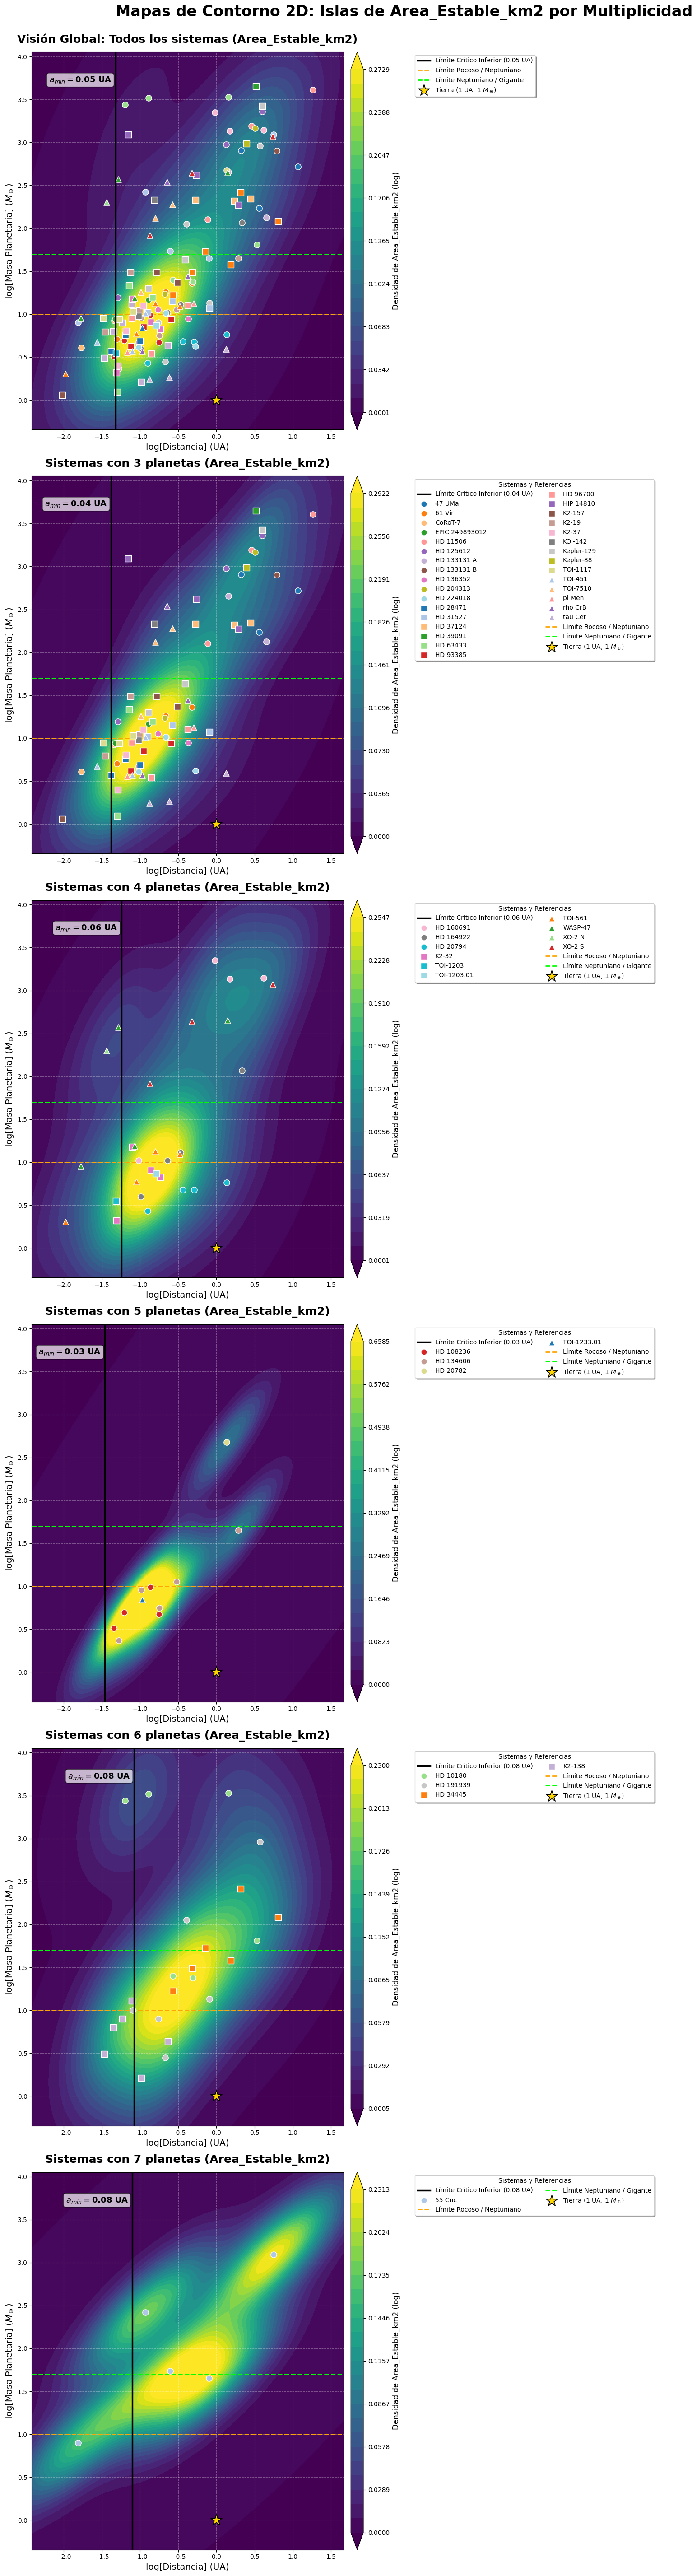

In [58]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        # 1. Extraer todos los datos (con arreglo de tildes y m1)
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            # 2. ACOTAR: Seleccionar solo sistemas con 3 o más planetas
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                plot_islands_zonas_estables(df_filtrado,DIRECTORIO_RAIZ)
              
            else:
                print("\n⚠️ No quedaron sistemas con 3 o más planetas tras aplicar el filtro.")
        else:
            print("\n❌ No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print("\n🛑 Operación cancelada por el usuario.")

F

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_F...
✅ Lectura completada. Se extrajeron datos válidos de 79 planetas.

Generando mapa de contornos 2D para: Area_Estable_km2...


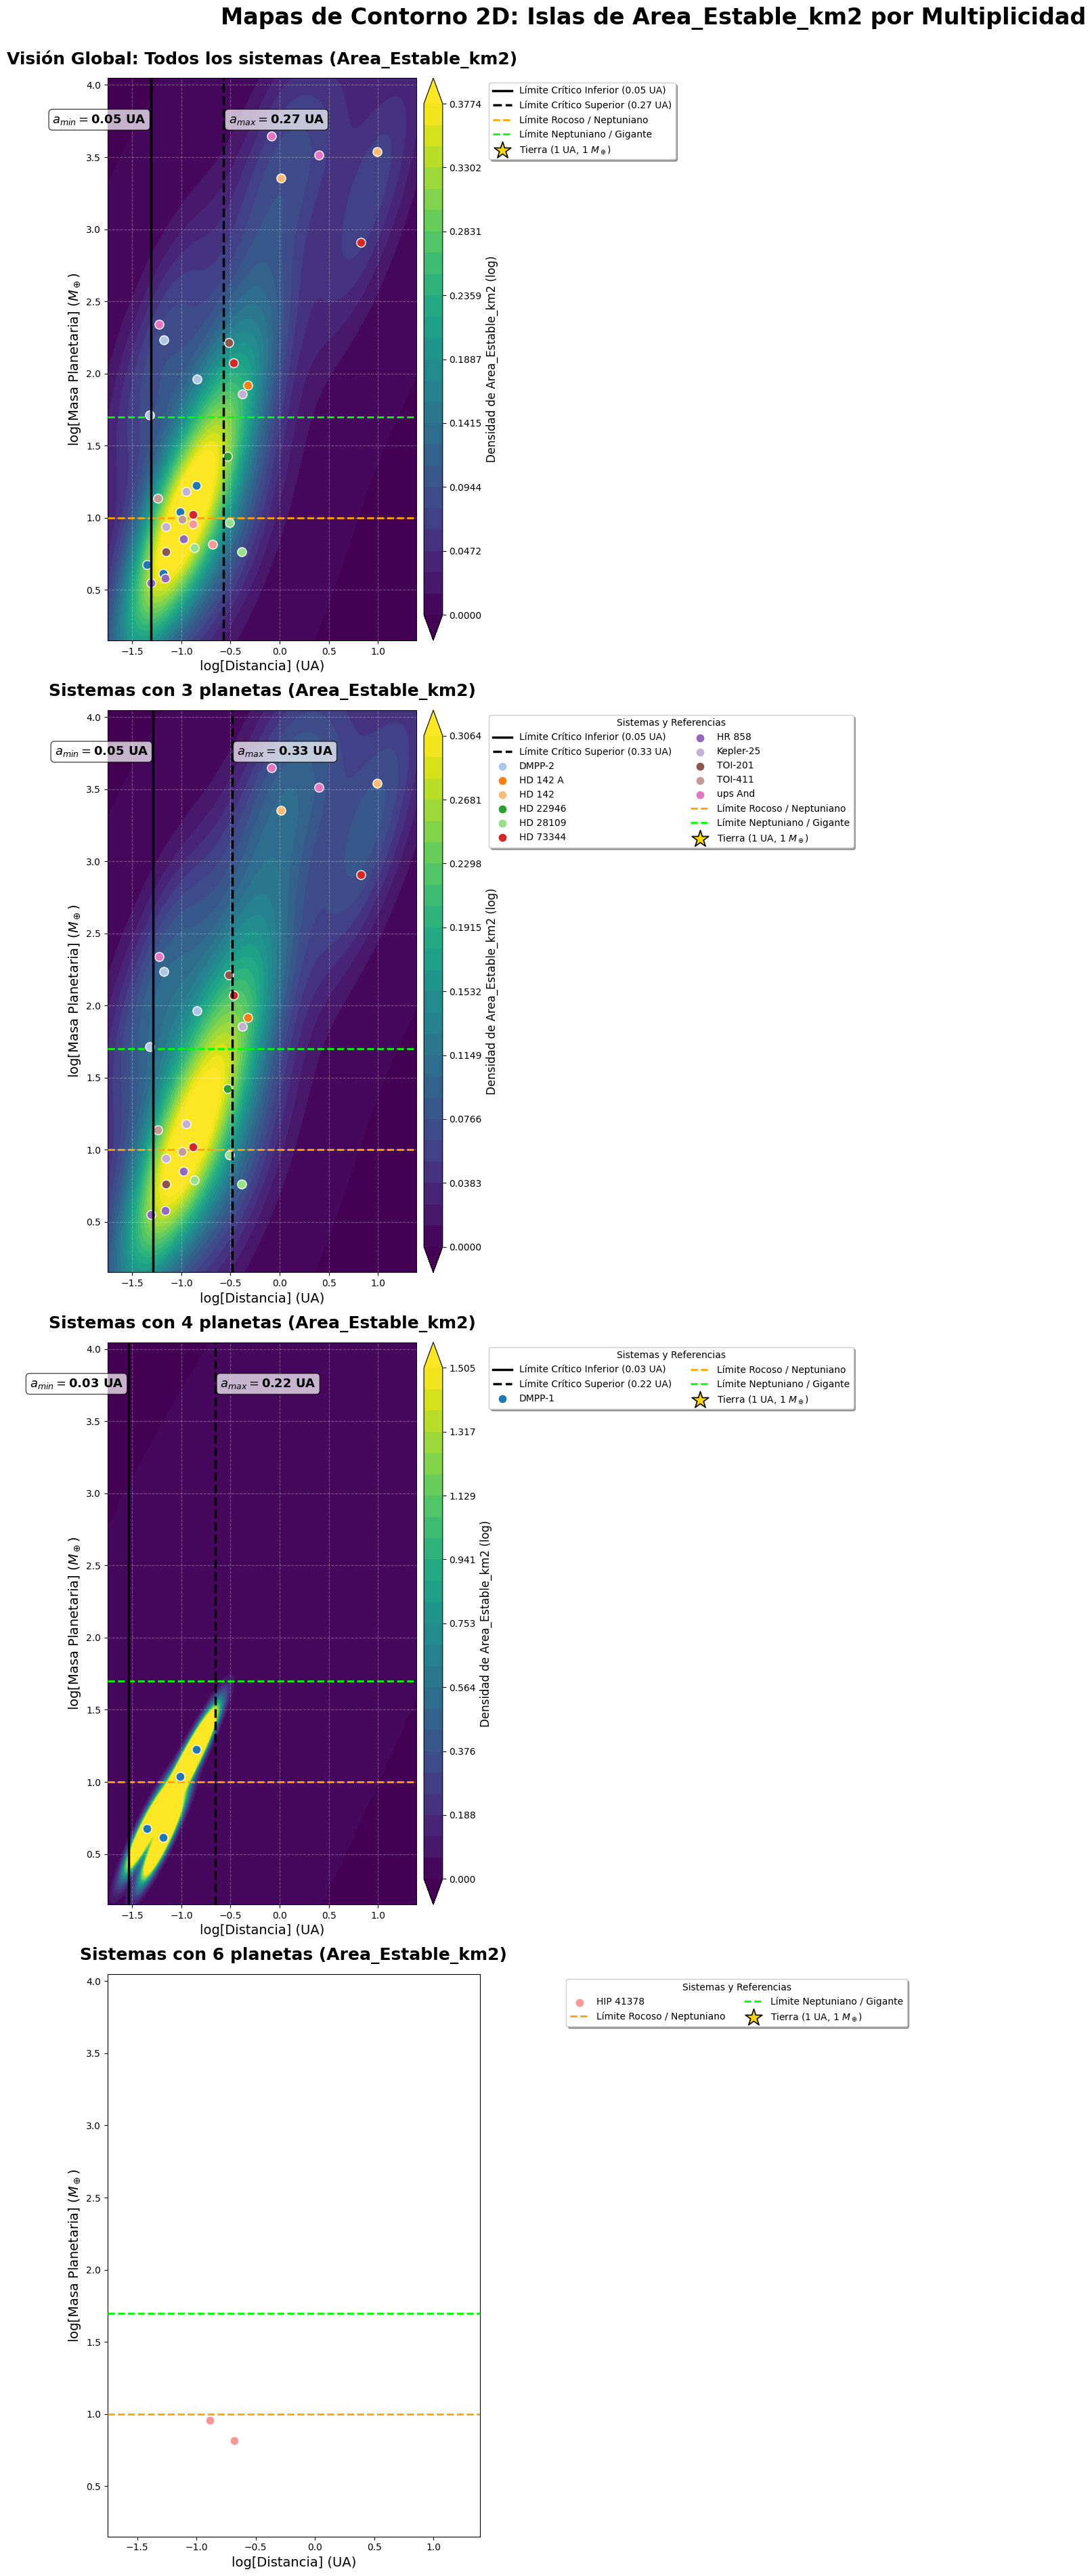

In [11]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        # 1. Extraer todos los datos (con arreglo de tildes y m1)
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            # 2. ACOTAR: Seleccionar solo sistemas con 3 o más planetas
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                plot_islands_zonas_estables2(df_filtrado,DIRECTORIO_RAIZ)
              
            else:
                print("\n⚠️ No quedaron sistemas con 3 o más planetas tras aplicar el filtro.")
        else:
            print("\n❌ No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print("\n🛑 Operación cancelada por el usuario.")

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_F...
✅ Lectura completada. Se extrajeron datos válidos de 79 planetas.

Generando mapa de contornos 2D para: Area_Estable_km2...


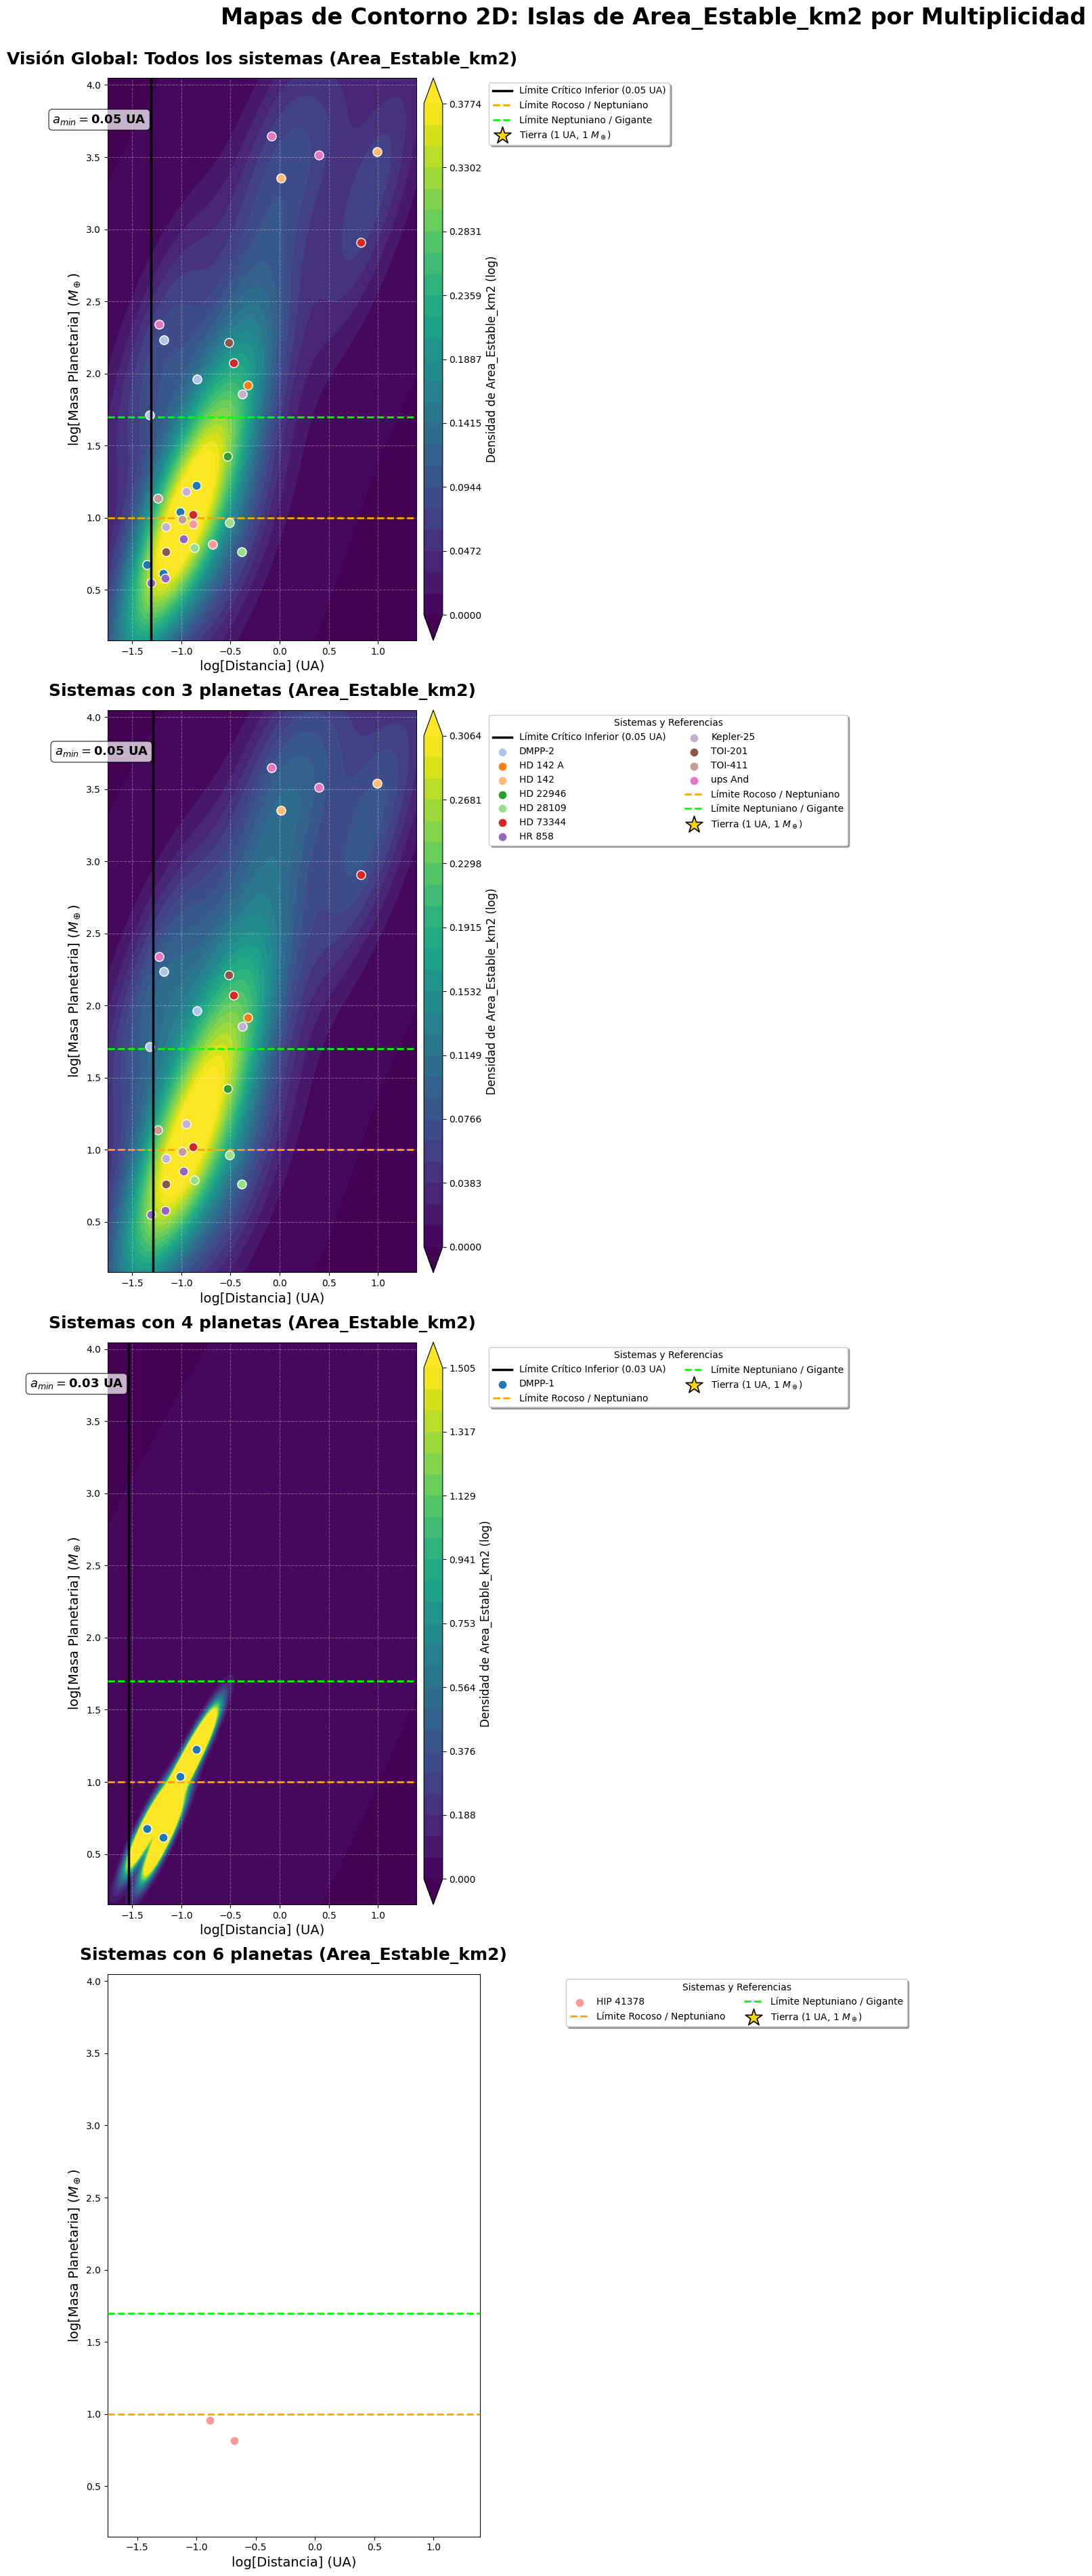

In [61]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        # 1. Extraer todos los datos (con arreglo de tildes y m1)
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            # 2. ACOTAR: Seleccionar solo sistemas con 3 o más planetas
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                plot_islands_zonas_estables(df_filtrado,DIRECTORIO_RAIZ)
              
            else:
                print("\n⚠️ No quedaron sistemas con 3 o más planetas tras aplicar el filtro.")
        else:
            print("\n❌ No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print("\n🛑 Operación cancelada por el usuario.")